In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_data = pd.read_csv("train_IPL.csv")
lb_matches_data = pd.read_csv("public_lb_matches.csv")
schedule_data = pd.read_csv("schedule.csv") 

C:\Users\ASHISH\AppData\Local\Temp\ipykernel_21324\2143635497.py:1: DtypeWarning: Columns (0: result_type, 1: season) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv("train_IPL.csv")


Data Clearning

In [4]:
train_data.columns

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings',
       'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs',
       'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket',
       'Dismissal Method', 'Player Out', 'Innings Runs', 'Innings Wickets',
       'Target Score', 'Runs to Get', 'Balls Remaining', 'Total Batter Runs',
       'Total Non Striker Runs', 'Batter Balls Faced',
       'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced',
       'Bowler Runs Conceded', 'Valid Ball', 'toss_winner', 'toss_decision',
       'city', 'result_type', 'season', 'match_won_by'],
      dtype='str')

In [5]:
lb_matches_data.isnull().sum()

match_id         0
date             0
season           0
team_a           0
team_b           2
venue            0
city             0
toss_winner      0
toss_decision    0
dtype: int64

In [6]:
schedule_data.isnull().sum()


match_id    0
date        0
team_a      0
team_b      0
venue       0
city        0
dtype: int64

In [7]:
train_data.isnull().sum()

Match ID                        0
Date                            0
Venue                           0
Bat First                       0
Bat Second                    309
Innings                         0
Over                            0
Ball                            0
Batter                          0
Non Striker                     0
Bowler                          0
Batter Runs                     0
Extra Runs                      0
Runs From Ball                  0
Ball Rebowled                   0
Extra Type                      0
Wicket                          0
Dismissal Method           259152
Player Out                 259152
Innings Runs                    0
Innings Wickets                 0
Target Score                    0
Runs to Get                141389
Balls Remaining                 0
Total Batter Runs               0
Total Non Striker Runs          0
Batter Balls Faced              0
Non Striker Balls Faced         0
Player Out Runs            259152
Player Out Bal

In [8]:
train_data['Dismissal Method'] = train_data['Dismissal Method'].fillna('Not Out')

In [9]:
train_data['Player Out'] = train_data['Player Out'].fillna('None')

In [10]:
train_data['Runs to Get'] = train_data['Runs to Get'].fillna(0)

In [11]:
train_data['result_type'] = train_data['result_type'].fillna('Normal')

In [12]:
lb_matches_data[lb_matches_data['team_b'].isnull()]

,match_id,date,season,team_a,team_b,venue,city,toss_winner,toss_decision
4,1473492,2025-05-05,2025,Delhi Capitals,NaN,Rajiv Gandhi International Stadium,Hyderabad,Sunrisers Hyderabad,field
7,1473495,2025-05-08,2025,Punjab Kings,NaN,Himachal Pradesh Cricket Association Stadium,Dharamsala,Punjab Kings,bat


In [13]:
lb_matches_data = lb_matches_data.dropna(subset=['team_b'])

drop leakage column , since it may reveal result it accurate result , may not be better for well prediction

In [14]:
train_data.columns

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings',
       'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs',
       'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket',
       'Dismissal Method', 'Player Out', 'Innings Runs', 'Innings Wickets',
       'Target Score', 'Runs to Get', 'Balls Remaining', 'Total Batter Runs',
       'Total Non Striker Runs', 'Batter Balls Faced',
       'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced',
       'Bowler Runs Conceded', 'Valid Ball', 'toss_winner', 'toss_decision',
       'city', 'result_type', 'season', 'match_won_by'],
      dtype='str')

In [15]:
leakage_columns = [
    'Innings',
    'Over',
    'Ball',
    'Batter',
    'Non Striker',
    'Bowler',
    'Batter Runs',
    'Extra Runs',
    'Runs From Ball',
    'Ball Rebowled',
    'Extra Type',
    'Wicket',
    'Dismissal Method',
    'Player Out',
    'Innings Runs',
    'Innings Wickets',
    'Target Score',
    'Runs to Get',
    'Balls Remaining',
    'Total Batter Runs',
    'Total Non Striker Runs',
    'Batter Balls Faced',
    'Non Striker Balls Faced',
    'Player Out Runs',
    'Player Out Balls Faced',
    'Bowler Runs Conceded',
    'Valid Ball',
    'result_type'
]

# Drop leakage columns
train_data_clean = train_data.drop(columns=leakage_columns, errors='ignore')

# Check remaining columns
print("Remaining Columns:\n")
print(train_data_clean.columns)

Remaining Columns:

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'toss_winner',
       'toss_decision', 'city', 'season', 'match_won_by'],
      dtype='str')


In [16]:
train_data_clean.head(5)

,Match ID,Date,Venue,Bat First,Bat Second,toss_winner,toss_decision,city,season,match_won_by
0,335982,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Bengaluru,2007/08,Kolkata Knight Riders
1,335982,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Bengaluru,2007/08,Kolkata Knight Riders
2,335982,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Bengaluru,2007/08,Kolkata Knight Riders
3,335982,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Bengaluru,2007/08,Kolkata Knight Riders
4,335982,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Bengaluru,2007/08,Kolkata Knight Riders


In [17]:
train_data_clean.duplicated()

0         False
1          True
2          True
3          True
4          True
          ...  
272699     True
272700     True
272701     True
272702     True
272703     True
Length: 272704, dtype: bool

remove duplicate from clean dataset so that ensure their is only one record per match ids

In [18]:
match_data = train_data_clean.groupby('Match ID').first().reset_index()

In [19]:
lb_matches_data = lb_matches_data.groupby('match_id').first().reset_index()
lb_matches_data.dtypes

match_id         int64
date               str
season           int64
team_a             str
team_b             str
venue              str
city               str
toss_winner        str
toss_decision      str
dtype: object

In [20]:
schedule_data = schedule_data.groupby('match_id').first().reset_index()
schedule_data.dtypes

match_id    str
date        str
team_a      str
team_b      str
venue       str
city        str
dtype: object

In [21]:
match_data['Date'] = pd.to_datetime(match_data['Date'])

# Convert integer columns
match_data['Match ID'] = match_data['Match ID'].astype('int64')
match_data['season'] = pd.to_numeric(match_data['season'], errors='coerce')

# Convert categorical columns
categorical_cols = [
    'Venue',
    'Bat First',
    'Bat Second',
    'toss_winner',
    'toss_decision',
    'city',
    'match_won_by'
]

for col in categorical_cols:
    match_data[col] = match_data[col].astype('category')

# Check datatypes
print(match_data.dtypes)

Match ID                  int64
Date             datetime64[us]
Venue                  category
Bat First              category
Bat Second             category
toss_winner            category
toss_decision          category
city                   category
season                  float64
match_won_by           category
dtype: object


In [22]:
# Convert date column
lb_matches_data['date'] = pd.to_datetime(lb_matches_data['date'])

# Convert integer columns
lb_matches_data['match_id'] = lb_matches_data['match_id'].astype('int64')
lb_matches_data['season'] = pd.to_numeric(lb_matches_data['season'], errors='coerce')

# Convert categorical/string columns
categorical_cols = [
    'team_a',
    'team_b',
    'venue',
    'city',
    'toss_winner',
    'toss_decision'
]

for col in categorical_cols:
    lb_matches_data[col] = lb_matches_data[col].astype('category')

# Check datatypes
print(lb_matches_data.dtypes)

match_id                  int64
date             datetime64[us]
season                    int64
team_a                 category
team_b                 category
venue                  category
city                   category
toss_winner            category
toss_decision          category
dtype: object


In [23]:
schedule_data.head()

,match_id,date,team_a,team_b,venue,city
0,M_2026_T01,2026-05-21,Chennai Super Kings,Gujarat Titans,MA Chidambaram Stadium,Chennai
1,M_2026_T02,2026-05-22,Sunrisers Hyderabad,Royal Challengers Bengaluru,Rajiv Gandhi International Stadium,Hyderabad
2,M_2026_T03,2026-05-23,Lucknow Super Giants,Punjab Kings,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow
3,M_2026_T04,2026-05-24,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,Mumbai
4,M_2026_T05,2026-05-24,Kolkata Knight Riders,Delhi Capitals,Eden Gardens,Kolkata


In [24]:
# Convert date column
schedule_data['date'] = pd.to_datetime(
    schedule_data['date']
)

# KEEP match_id as string
schedule_data['match_id'] = (
    schedule_data['match_id']
    .astype(str)
)

# Convert categorical columns
categorical_cols = [
    'team_a',
    'team_b',
    'venue',
    'city'
]

for col in categorical_cols:

    schedule_data[col] = (
        schedule_data[col]
        .astype('category')
    )

# Check datatypes
print(schedule_data.dtypes)

match_id               str
date        datetime64[us]
team_a            category
team_b            category
venue             category
city              category
dtype: object


fix inconsistent data from train ipl csv file 

In [25]:
print(match_data['Bat First'].unique())
print(match_data['Bat Second'].unique())
print(match_data['toss_winner'].unique())

['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers', ..., 'Delhi Capitals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans', 'Royal Challengers Bengaluru']
Length: 19
Categories (19, str): ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', ..., 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
['Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi Daredevils', 'Kolkata Knight Riders', 'Rajasthan Royals', ..., 'Delhi Capitals', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants', 'Royal Challengers Bengaluru']
Length: 20
Categories (19, str): ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', ..., 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
['Royal Challengers Bangalore', 'Chennai Super Kings', 'Rajasthan Royals', 'Mumbai Indians',

In [26]:
current_ipl_teams = [
    'Mumbai Indians',
    'Chennai Super Kings',
    'Royal Challengers Bengaluru',
    'Kolkata Knight Riders',
    'Delhi Capitals',
    'Punjab Kings',
    'Rajasthan Royals',
    'Sunrisers Hyderabad',
    'Gujarat Titans',
    'Lucknow Super Giants'
]

In [27]:
match_data = match_data[
    match_data['Bat First'].isin(current_ipl_teams) &
    match_data['Bat Second'].isin(current_ipl_teams) &
    match_data['toss_winner'].isin(current_ipl_teams)
]

some teams their name are changed in current ipl season

In [28]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

team_cols = [
    'Bat First',
    'Bat Second',
    'toss_winner',
    'match_won_by'
]

for col in team_cols:
    match_data[col] = match_data[col].replace(team_mapping)

In [29]:
# Remove discontinued IPL teams

old_teams = [
    'Deccan Chargers',
    'Pune Warriors India',
    'Rising Pune Supergiant',
    'Rising Pune Supergiants',
    'Kochi Tuskers Kerala',
    'Gujarat Lions'
]

match_data = match_data[
    ~match_data['Bat First'].isin(old_teams) &
    ~match_data['Bat Second'].isin(old_teams) & 
    ~match_data['toss_winner'].isin(old_teams)
]

print(match_data.shape)

(516, 10)


In [30]:
print(match_data['Bat First'].unique())

['Chennai Super Kings', 'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians', 'Sunrisers Hyderabad', 'Delhi Capitals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans', 'Royal Challengers Bengaluru']
Categories (19, str): ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', ..., 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [31]:
categorical_cols = [
    'Bat First',
    'Bat Second',
    'toss_winner',
    'match_won_by'
]

for col in categorical_cols:
    match_data[col] = (
        match_data[col]
        .cat.remove_unused_categories()
    )

In [32]:
print(match_data['Bat First'].unique())

['Chennai Super Kings', 'Kolkata Knight Riders', 'Rajasthan Royals', 'Mumbai Indians', 'Sunrisers Hyderabad', 'Delhi Capitals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans', 'Royal Challengers Bengaluru']
Categories (10, str): ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', ..., 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


Exploratory data analysis

In [33]:
print(match_data['Bat First'].value_counts())

Bat First
Chennai Super Kings            84
Mumbai Indians                 81
Rajasthan Royals               70
Kolkata Knight Riders          69
Sunrisers Hyderabad            68
Delhi Capitals                 40
Punjab Kings                   35
Lucknow Super Giants           29
Gujarat Titans                 25
Royal Challengers Bengaluru    15
Name: count, dtype: int64


In [34]:
print(match_data['Bat Second'].value_counts())

Bat Second
Kolkata Knight Riders          88
Mumbai Indians                 84
Rajasthan Royals               78
Chennai Super Kings            74
Sunrisers Hyderabad            62
Delhi Capitals                 48
Gujarat Titans                 26
Punjab Kings                   26
Lucknow Super Giants           20
Royal Challengers Bengaluru    10
Name: count, dtype: int64


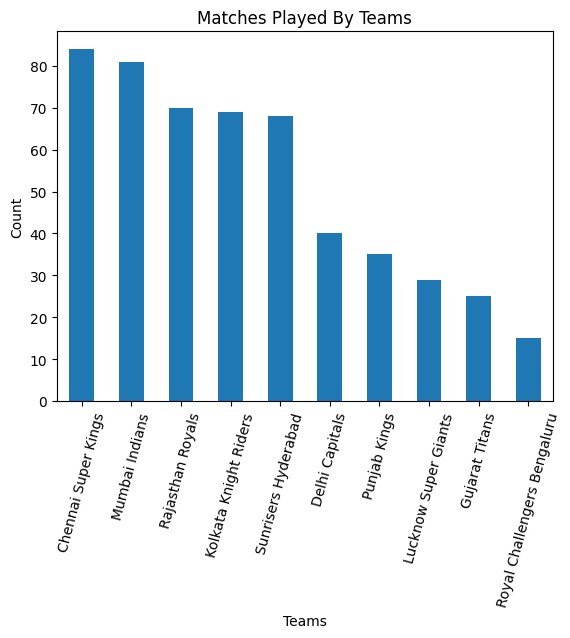

In [35]:


match_data['Bat First'].value_counts().plot(kind='bar')

plt.title("Matches Played By Teams")
plt.xlabel("Teams")
plt.ylabel("Count")

plt.xticks(rotation=75)

plt.show()

In [36]:
match_data['match_won_by'].value_counts()

match_won_by
Mumbai Indians                 92
Chennai Super Kings            83
Kolkata Knight Riders          70
Rajasthan Royals               66
Sunrisers Hyderabad            52
Delhi Capitals                 44
Gujarat Titans                 32
Lucknow Super Giants           28
Punjab Kings                   27
Royal Challengers Bengaluru    14
Unknown                         8
Name: count, dtype: int64

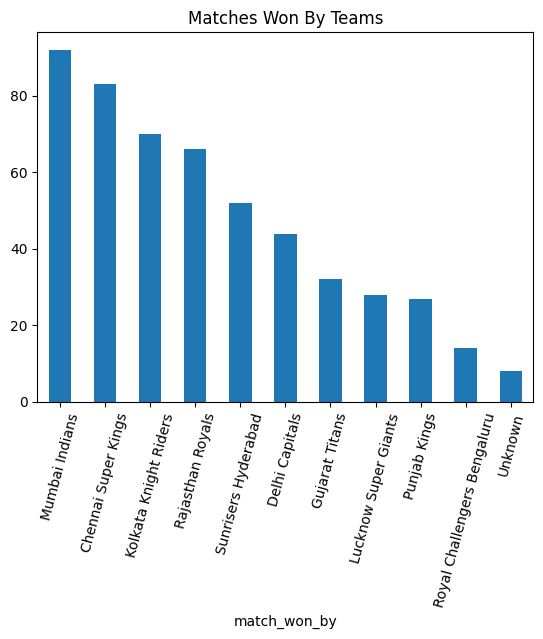

In [37]:
match_data['match_won_by'].value_counts().plot(kind='bar')

plt.title("Matches Won By Teams")

plt.xticks(rotation=75)

plt.show()

Engineering features 

In [38]:
team_wins = match_data['match_won_by'].value_counts()

In [39]:
team_matches = pd.concat([
    match_data['Bat First'],
    match_data['Bat Second']
]).value_counts() 

In [40]:
team_win_rate = (
    team_wins / team_matches
).fillna(0)

print(team_win_rate)

match_won_by
Chennai Super Kings            0.525316
Delhi Capitals                 0.500000
Gujarat Titans                 0.627451
Kolkata Knight Riders          0.445860
Lucknow Super Giants           0.571429
Mumbai Indians                 0.557576
Punjab Kings                   0.442623
Rajasthan Royals               0.445946
Royal Challengers Bengaluru    0.560000
Sunrisers Hyderabad            0.400000
Unknown                        0.000000
Name: count, dtype: float64


In [41]:
match_data['team1_win_rate'] = (
    match_data['Bat First']
    .map(team_win_rate)
)

match_data['team2_win_rate'] = (
    match_data['Bat Second']
    .map(team_win_rate)
)

In [42]:
print(match_data['season'])

7          NaN
11         NaN
15         NaN
18         NaN
23         NaN
         ...  
1140    2025.0
1141    2025.0
1142    2025.0
1143    2025.0
1144    2025.0
Name: season, Length: 516, dtype: float64


In [43]:
venue_team_wins = (
    match_data.groupby(['Venue', 'match_won_by'])
    .size()
) 
print(venue_team_wins)

Venue                  match_won_by         
Arun Jaitley Stadium   Chennai Super Kings      3
                       Delhi Capitals           6
                       Gujarat Titans           1
                       Kolkata Knight Riders    1
                       Mumbai Indians           5
                                               ..
Zayed Cricket Stadium  Chennai Super Kings      1
                       Delhi Capitals           1
                       Kolkata Knight Riders    1
                       Mumbai Indians           2
                       Rajasthan Royals         1
Length: 174, dtype: int64


2) head to head

In [44]:
def head_to_head(team1, team2, df):

    matches = df[
        (
            (df['Bat First'] == team1) &
            (df['Bat Second'] == team2)
        ) |
        (
            (df['Bat First'] == team2) &
            (df['Bat Second'] == team1)
        )
    ]

    team1_wins = (
        matches['match_won_by'] == team1
    ).sum()

    total = len(matches)

    if total == 0:
        return 0.5

    return team1_wins / total 

In [45]:
h2h_feature = []

for idx, row in match_data.iterrows():

    previous_matches = match_data.iloc[:idx]

    h2h_feature.append(
        head_to_head(
            row['Bat First'],
            row['Bat Second'],
            previous_matches
        )
    )

match_data['head_to_head'] = h2h_feature 
print(match_data[['Bat First', 'Bat Second', 'head_to_head']].tail(5))

                  Bat First                   Bat Second  head_to_head
1140         Delhi Capitals  Royal Challengers Bengaluru      0.333333
1141         Gujarat Titans             Rajasthan Royals      0.750000
1142  Kolkata Knight Riders               Delhi Capitals      0.461538
1143    Chennai Super Kings                 Punjab Kings      0.222222
1144         Mumbai Indians             Rajasthan Royals      0.533333


feature selection 

In [46]:
numeric_data = match_data.select_dtypes(include=['int64', 'float64'])

In [47]:
corr_matrix = numeric_data.corr()

print(corr_matrix)

              Match ID    season  head_to_head
Match ID      1.000000  0.987683      0.039019
season        0.987683  1.000000      0.012217
head_to_head  0.039019  0.012217      1.000000


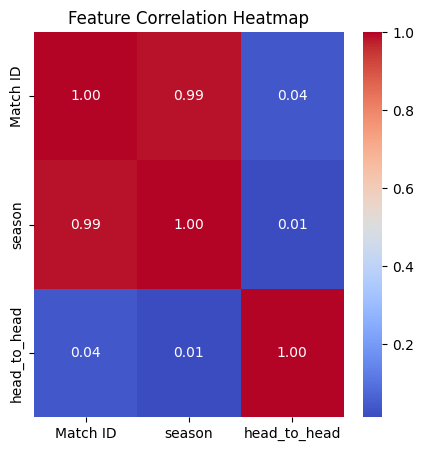

In [48]:
plt.figure(figsize=(5, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

target Creation 

In [49]:
extra_cols = pd.read_csv(
    "train_IPL.csv",
    usecols=[
        'Match ID',
        'result_type',
        'Runs to Get',
        'Innings Wickets'
    ],
    low_memory=False,
    on_bad_lines='skip'
)

In [50]:
extra_cols = (
    extra_cols.groupby('Match ID')
    .last()
    .reset_index()
)

In [51]:
match_data = match_data.merge(
    extra_cols,
    on='Match ID',
    how='left'
)

In [52]:
print(match_data.columns)

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'toss_winner',
       'toss_decision', 'city', 'season', 'match_won_by', 'team1_win_rate',
       'team2_win_rate', 'head_to_head', 'Innings Wickets', 'Runs to Get',
       'result_type'],
      dtype='str')


In [53]:
extra_cols = (
    extra_cols.groupby('Match ID')
    .last()
    .reset_index()
)

In [54]:
extra_cols['Runs to Get'] = (
    extra_cols['Runs to Get']
    .fillna(0)
)

In [55]:
def create_target(row):

    winner = row['match_won_by']
    result_type = row['result_type']

    team_a = row['Bat First']

    # BIG WIN CONDITION
    if result_type == 'runs':

        # Runs margin
        margin = row['Runs to Get']

        big_win = margin > 20

    else:

        # Wickets margin
        wickets_margin = 10 - row['Innings Wickets']

        big_win = wickets_margin >= 6

    # TEAM A WON
    if winner == team_a:

        return 'A_big' if big_win else 'A_small'

    # TEAM B WON
    else:

        return 'B_big' if big_win else 'B_small'

In [56]:
match_data['target'] = match_data.apply(
    create_target,
    axis=1
)

In [57]:
print(match_data['target'].value_counts())

target
A_small    224
B_big      182
B_small    105
A_big        5
Name: count, dtype: int64


In [58]:
print(
    match_data['target']
    .value_counts(normalize=True)
)

target
A_small    0.434109
B_big      0.352713
B_small    0.203488
A_big      0.009690
Name: proportion, dtype: float64


In [59]:
X = match_data.drop(columns=[
    'match_won_by',
    'target',
    'result_type',
    'Runs to Get',
    'Innings Wickets'
])

In [60]:
y = match_data['target']

In [61]:
print(X.columns)

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'toss_winner',
       'toss_decision', 'city', 'season', 'team1_win_rate', 'team2_win_rate',
       'head_to_head'],
      dtype='str')


In [62]:
print(X.shape)
print(y.shape)

print(X.head())

(516, 12)
(516,)
   Match ID       Date                   Venue              Bat First  \
0    335989 2008-04-23  MA Chidambaram Stadium    Chennai Super Kings   
1    335993 2008-04-26  MA Chidambaram Stadium  Kolkata Knight Riders   
2    335997 2008-04-29            Eden Gardens  Kolkata Knight Riders   
3    336000 2008-05-01  Sawai Mansingh Stadium       Rajasthan Royals   
4    336005 2008-05-04  Sawai Mansingh Stadium    Chennai Super Kings   

              Bat Second            toss_winner toss_decision     city  \
0         Mumbai Indians         Mumbai Indians         field  Chennai   
1    Chennai Super Kings  Kolkata Knight Riders           bat  Chennai   
2         Mumbai Indians  Kolkata Knight Riders           bat  Kolkata   
3  Kolkata Knight Riders       Rajasthan Royals           bat   Jaipur   
4       Rajasthan Royals    Chennai Super Kings           bat   Jaipur   

   season team1_win_rate team2_win_rate  head_to_head  
0     NaN       0.525316       0.557576    

In [63]:
cat_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(cat_features)

['Venue', 'Bat First', 'Bat Second', 'toss_winner', 'toss_decision', 'city', 'team1_win_rate', 'team2_win_rate']


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
from catboost import CatBoostClassifier

In [66]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    verbose=100
)

In [67]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=1]="2023-04-19T00:00:00.000000": Cannot convert obj 2023-04-19T00:00:00.000000 to float

In [68]:
X['year'] = X['Date'].dt.year
X['month'] = X['Date'].dt.month
X['day'] = X['Date'].dt.day
X['dayofweek'] = X['Date'].dt.dayofweek

In [69]:
X = X.drop(columns=['Date'])

In [70]:
X['team1_win_rate'] = pd.to_numeric(
    X['team1_win_rate'],
    errors='coerce'
)

X['team2_win_rate'] = pd.to_numeric(
    X['team2_win_rate'],
    errors='coerce'
)

X['team1_win_rate'] = (
    X['team1_win_rate']
    .fillna(0)
)

X['team2_win_rate'] = (
    X['team2_win_rate']
    .fillna(0)
)

In [71]:
print(X.dtypes)

Match ID             int64
Venue             category
Bat First         category
Bat Second        category
toss_winner       category
toss_decision     category
city              category
season             float64
team1_win_rate     float64
team2_win_rate     float64
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object


In [72]:
cat_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(cat_features)

['Venue', 'Bat First', 'Bat Second', 'toss_winner', 'toss_decision', 'city']


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 1.3668542	total: 154ms	remaining: 1m 16s
100:	learn: 0.8835641	total: 4.35s	remaining: 17.2s
200:	learn: 0.6657117	total: 9.31s	remaining: 13.8s
300:	learn: 0.5129977	total: 14.2s	remaining: 9.38s
400:	learn: 0.4042839	total: 19s	remaining: 4.7s
499:	learn: 0.3293815	total: 23.8s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='MultiClass', iterations=500, learning_rate=0.05, loss_function='MultiClass', verbose=100)

In [75]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.5


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       A_big       0.00      0.00      0.00         1
     A_small       0.49      0.71      0.58        45
       B_big       0.53      0.49      0.51        37
     B_small       0.40      0.10      0.15        21

    accuracy                           0.50       104
   macro avg       0.36      0.32      0.31       104
weighted avg       0.48      0.50      0.46       104



C:\Users\ASHISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASHISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASHISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_c

In [77]:
pred_probs = model.predict_proba(X_test)
print(pred_probs)

[[0.00443794 0.46202525 0.44326746 0.09026936]
 [0.0314002  0.46433246 0.33147542 0.17279192]
 [0.00540788 0.62998943 0.22613652 0.13846617]
 [0.00711759 0.50865749 0.23502165 0.24920327]
 [0.07455551 0.32536647 0.16295894 0.43711908]
 [0.0038673  0.81778181 0.14807969 0.0302712 ]
 [0.00705967 0.44014097 0.44950352 0.10329584]
 [0.00774654 0.61339731 0.25379325 0.12506291]
 [0.00382343 0.7342486  0.20251737 0.0594106 ]
 [0.04229786 0.68188843 0.21178645 0.06402727]
 [0.01034653 0.34813658 0.51066238 0.13085451]
 [0.0110029  0.83342944 0.12632616 0.02924151]
 [0.00523009 0.38248194 0.23715166 0.37513631]
 [0.00548559 0.32796167 0.53929266 0.12726007]
 [0.01299011 0.48084676 0.3515556  0.15460753]
 [0.00617147 0.71258389 0.12821491 0.15302973]
 [0.0052631  0.33149988 0.40609977 0.25713725]
 [0.00310909 0.09845577 0.50116648 0.39726867]
 [0.01220017 0.53401506 0.24201129 0.21177348]
 [0.00520277 0.60224997 0.29717875 0.09536851]
 [0.03659897 0.70117039 0.19998593 0.06224471]
 [0.0084986  

In [78]:
print(model.classes_)

['A_big' 'A_small' 'B_big' 'B_small']


In [79]:
prob_data = pd.DataFrame(
    pred_probs,
    columns=model.classes_
)

print(prob_data.head())

      A_big   A_small     B_big   B_small
0  0.004438  0.462025  0.443267  0.090269
1  0.031400  0.464332  0.331475  0.172792
2  0.005408  0.629989  0.226137  0.138466
3  0.007118  0.508657  0.235022  0.249203
4  0.074556  0.325366  0.162959  0.437119


In [80]:
lb_matches_data.dtypes

match_id                  int64
date             datetime64[us]
season                    int64
team_a                 category
team_b                 category
venue                  category
city                   category
toss_winner            category
toss_decision          category
dtype: object

In [81]:
X.dtypes

Match ID             int64
Venue             category
Bat First         category
Bat Second        category
toss_winner       category
toss_decision     category
city              category
season             float64
team1_win_rate     float64
team2_win_rate     float64
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object

In [82]:
lb_matches_data = lb_matches_data.rename(columns={
    'venue': 'Venue',
    'team_a': 'Bat First',
    'team_b': 'Bat Second',
    'date': 'Date'
})

In [83]:
lb_matches_data['team1_win_rate'] = (
    lb_matches_data['Bat First']
    .map(team_win_rate)
)

lb_matches_data['team2_win_rate'] = (
    lb_matches_data['Bat Second']
    .map(team_win_rate)
)

In [84]:
h2h_dict = {}

teams = match_data['Bat First'].unique()

for team1 in teams:

    for team2 in teams:

        if team1 == team2:
            continue

        matches = match_data[
            (
                (match_data['Bat First'] == team1) &
                (match_data['Bat Second'] == team2)
            ) |
            (
                (match_data['Bat First'] == team2) &
                (match_data['Bat Second'] == team1)
            )
        ]

        total_matches = len(matches)

        if total_matches == 0:

            h2h_dict[(team1, team2)] = 0.5

        else:

            team1_wins = (
                matches['match_won_by'] == team1
            ).sum()

            h2h_dict[(team1, team2)] = (
                team1_wins / total_matches
            )

In [85]:
def get_h2h(row):

    return h2h_dict.get(
        (
            row['Bat First'],
            row['Bat Second']
        ),
        0.5
    ) 

lb_matches_data['head_to_head'] = (
    lb_matches_data.apply(
        get_h2h,
        axis=1
    )
)

In [86]:
lb_matches_data['year'] = (
    lb_matches_data['Date'].dt.year
)

lb_matches_data['month'] = (
    lb_matches_data['Date'].dt.month
)

lb_matches_data['day'] = (
    lb_matches_data['Date'].dt.day
)

lb_matches_data['dayofweek'] = (
    lb_matches_data['Date'].dt.dayofweek
)

In [87]:
lb_matches_data = lb_matches_data.drop(
    columns=['Date']
)

In [88]:
lb_matches_data['season'] = (
    lb_matches_data['season']
    .astype('float64')
)

In [89]:
print(lb_matches_data.columns)

Index(['match_id', 'season', 'Bat First', 'Bat Second', 'Venue', 'city',
       'toss_winner', 'toss_decision', 'team1_win_rate', 'team2_win_rate',
       'head_to_head', 'year', 'month', 'day', 'dayofweek'],
      dtype='str')


In [90]:
print(X.columns)

Index(['Match ID', 'Venue', 'Bat First', 'Bat Second', 'toss_winner',
       'toss_decision', 'city', 'season', 'team1_win_rate', 'team2_win_rate',
       'head_to_head', 'year', 'month', 'day', 'dayofweek'],
      dtype='str')


In [91]:
X = X.drop(columns=['Match ID'])

In [93]:
lb_matches_data = lb_matches_data[X.columns]

In [92]:
print(lb_matches_data.dtypes)

match_id             int64
season             float64
Bat First         category
Bat Second        category
Venue             category
city              category
toss_winner       category
toss_decision     category
team1_win_rate    category
team2_win_rate    category
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object


In [94]:
X.dtypes

Venue             category
Bat First         category
Bat Second        category
toss_winner       category
toss_decision     category
city              category
season             float64
team1_win_rate     float64
team2_win_rate     float64
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object

In [95]:
lb_matches_data['team1_win_rate'] = pd.to_numeric(
    lb_matches_data['team1_win_rate'],
    errors='coerce'
)

lb_matches_data['team2_win_rate'] = pd.to_numeric(
    lb_matches_data['team2_win_rate'],
    errors='coerce'
)

In [96]:
print(lb_matches_data.dtypes)

Venue             category
Bat First         category
Bat Second        category
toss_winner       category
toss_decision     category
city              category
season             float64
team1_win_rate     float64
team2_win_rate     float64
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object


again train for lb data

In [97]:
cat_cols = [
    'Venue',
    'Bat First',
    'Bat Second',
    'toss_winner',
    'toss_decision',
    'city'
]

for col in cat_cols:

    X[col] = X[col].astype(str)

In [98]:
print(lb_matches_data.columns)

Index(['Venue', 'Bat First', 'Bat Second', 'toss_winner', 'toss_decision',
       'city', 'season', 'team1_win_rate', 'team2_win_rate', 'head_to_head',
       'year', 'month', 'day', 'dayofweek'],
      dtype='str')


In [99]:
for col in cat_cols:

    lb_matches_data[col] = (
        lb_matches_data[col]
        .astype(str)
    ) 



In [100]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    verbose=100
)

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [102]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

0:	learn: 1.3642314	total: 23.5ms	remaining: 11.7s
100:	learn: 0.8529432	total: 3.73s	remaining: 14.7s
200:	learn: 0.6320195	total: 7.84s	remaining: 11.7s
300:	learn: 0.4854912	total: 12.2s	remaining: 8.09s
400:	learn: 0.3863516	total: 16.6s	remaining: 4.11s
499:	learn: 0.3140305	total: 20.9s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='MultiClass', verbose=100)

In [103]:
test_probs = model.predict_proba(
    lb_matches_data
)

In [104]:
submission_lb = pd.DataFrame(
    test_probs,
    columns=model.classes_
) 
print(submission_lb.head(5))

      A_big   A_small     B_big   B_small
0  0.002287  0.846945  0.121901  0.028867
1  0.003279  0.696725  0.118412  0.181583
2  0.004629  0.503883  0.353520  0.137968
3  0.004427  0.248402  0.561347  0.185824
4  0.005522  0.262004  0.572172  0.160302


In [105]:
match_ids = lb_matches_data.index

In [106]:
lb_match_ids = pd.read_csv(
    "public_lb_matches.csv",
    usecols=['match_id']
)

In [107]:
print(lb_match_ids.head())

   match_id
0   1473488
1   1473489
2   1473490
3   1473491
4   1473492


In [108]:
submission_lb = submission_lb.reset_index(
    drop=True
)

lb_match_ids = lb_match_ids.reset_index(
    drop=True
)

In [109]:
submission_lb.insert(
    0,
    'match_id',
    lb_match_ids.loc[
        :len(submission_lb)-1,
        'match_id'
    ].values
)

In [110]:
print(submission_lb.shape)
print(submission_lb.head())

(46, 5)
   match_id     A_big   A_small     B_big   B_small
0   1473488  0.002287  0.846945  0.121901  0.028867
1   1473489  0.003279  0.696725  0.118412  0.181583
2   1473490  0.004629  0.503883  0.353520  0.137968
3   1473491  0.004427  0.248402  0.561347  0.185824
4   1473492  0.005522  0.262004  0.572172  0.160302


In [111]:
submission_lb = submission_lb[
    [
        'match_id',
        'A_small',
        'A_big',
        'B_small',
        'B_big'
    ]
]

In [ ]:
submission.to_csv(
    "sample_submission.csv",
    index=False
)

print("Submission file created successfully!")

NameError: name 'submission' is not defined

In [114]:
submission.head(5)

NameError: name 'submission' is not defined

In [115]:
schedule_match_ids = schedule_data['match_id']

In [116]:
schedule_data.head()

,match_id,date,team_a,team_b,venue,city
0,M_2026_T01,2026-05-21,Chennai Super Kings,Gujarat Titans,MA Chidambaram Stadium,Chennai
1,M_2026_T02,2026-05-22,Sunrisers Hyderabad,Royal Challengers Bengaluru,Rajiv Gandhi International Stadium,Hyderabad
2,M_2026_T03,2026-05-23,Lucknow Super Giants,Punjab Kings,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow
3,M_2026_T04,2026-05-24,Mumbai Indians,Rajasthan Royals,Wankhede Stadium,Mumbai
4,M_2026_T05,2026-05-24,Kolkata Knight Riders,Delhi Capitals,Eden Gardens,Kolkata


In [117]:
schedule_data = schedule_data.rename(columns={
    'venue': 'Venue',
    'team_a': 'Bat First',
    'team_b': 'Bat Second',
    'date': 'Date'
})

In [118]:
schedule_data['season'] = 2026

In [119]:
schedule_data['toss_winner'] = (
    schedule_data['Bat First']
)

In [120]:
schedule_data['toss_decision'] = 'field'

In [121]:
schedule_data['team1_win_rate'] = (
    schedule_data['Bat First']
    .map(team_win_rate)
)

schedule_data['team2_win_rate'] = (
    schedule_data['Bat Second']
    .map(team_win_rate)
)

In [122]:
def get_h2h(row):

    return h2h_dict.get(
        (
            row['Bat First'],
            row['Bat Second']
        ),
        0.5
    )

schedule_data['head_to_head'] = (
    schedule_data.apply(
        get_h2h,
        axis=1
    )
)

In [123]:
schedule_data['year'] = (
    schedule_data['Date'].dt.year
)

schedule_data['month'] = (
    schedule_data['Date'].dt.month
)

schedule_data['day'] = (
    schedule_data['Date'].dt.day
)

schedule_data['dayofweek'] = (
    schedule_data['Date'].dt.dayofweek
)

In [124]:
schedule_data = schedule_data.drop(
    columns=['Date']
)

In [125]:
presv = schedule_data

In [126]:
numeric_cols = [
    'season',
    'team1_win_rate',
    'team2_win_rate',
    'head_to_head'
]

for col in numeric_cols:

    schedule_data[col] = pd.to_numeric(
        schedule_data[col],
        errors='coerce'
    )

In [127]:
schedule_data['toss_decision'] = (
    schedule_data['toss_decision']
    .astype('category')
)

In [128]:
schedule_data['team1_win_rate'] = (
    schedule_data['team1_win_rate']
    .astype('float64')
)

schedule_data['team2_win_rate'] = (
    schedule_data['team2_win_rate']
    .astype('float64')
)

In [129]:
schedule_data = schedule_data[X.columns]
schedule_data.dtypes

Venue             category
Bat First         category
Bat Second        category
toss_winner       category
toss_decision     category
city              category
season               int64
team1_win_rate     float64
team2_win_rate     float64
head_to_head       float64
year                 int32
month                int32
day                  int32
dayofweek            int32
dtype: object

In [130]:
cat_cols = [
    'Venue',
    'Bat First',
    'Bat Second',
    'toss_winner',
    'toss_decision',
    'city'
]

for col in cat_cols:

    schedule_data[col] = (
        schedule_data[col]
        .astype(str)
    )

In [131]:
schedule_data['season'] = (
    schedule_data['season']
    .astype('float64')
)

In [132]:
print(schedule_data.dtypes)

Venue                 str
Bat First             str
Bat Second            str
toss_winner           str
toss_decision         str
city                  str
season            float64
team1_win_rate    float64
team2_win_rate    float64
head_to_head      float64
year                int32
month               int32
day                 int32
dayofweek           int32
dtype: object


In [133]:
X.dtypes

Venue                 str
Bat First             str
Bat Second            str
toss_winner           str
toss_decision         str
city                  str
season            float64
team1_win_rate    float64
team2_win_rate    float64
head_to_head      float64
year                int32
month               int32
day                 int32
dayofweek           int32
dtype: object

In [134]:
schedule_probs = model.predict_proba(
    schedule_data
)

In [135]:
schedule_match_ids = presv['match_id']

In [136]:
submission_schedule = pd.DataFrame(
    schedule_probs,
    columns=model.classes_
)

In [137]:
submission_schedule.insert(
    0,
    'match_id',
    schedule_match_ids.values
)

In [138]:
submission_schedule = submission_schedule[
    [
        'match_id',
        'A_small',
        'A_big',
        'B_small',
        'B_big'
    ]
] 

print(submission_schedule.head(5))

     match_id   A_small     A_big   B_small     B_big
0  M_2026_T01  0.396315  0.003178  0.221529  0.378978
1  M_2026_T02  0.376548  0.002669  0.192911  0.427871
2  M_2026_T03  0.608554  0.007685  0.225387  0.158374
3  M_2026_T04  0.431164  0.003423  0.219278  0.346136
4  M_2026_T05  0.302164  0.004520  0.262304  0.431012


In [139]:
final_submission = pd.concat(
    [
        submission_lb,
        submission_schedule
    ],
    ignore_index=True
)

In [140]:
print(final_submission.shape)

(51, 5)


In [152]:
final_submission = final_submission[
    [
        'match_id',
        'A_small',
        'A_big',
        'B_small',
        'B_big'
    ]
] 

In [153]:
sample_submission = pd.read_csv(
    "sample_submission.csv"
)

print(sample_submission.head())

   match_id   A_small     A_big   B_small     B_big
0         0  0.730625  0.004137  0.069235  0.196003
1         1  0.810982  0.004086  0.074723  0.110209
2         2  0.511890  0.003316  0.087500  0.397295
3         3  0.432364  0.007767  0.221510  0.338359
4         4  0.465812  0.003948  0.187855  0.342385


In [143]:
print(final_submission.head())

  match_id   A_small     A_big   B_small     B_big
0  1473488  0.846945  0.002287  0.028867  0.121901
1  1473489  0.696725  0.003279  0.181583  0.118412
2  1473490  0.503883  0.004629  0.137968  0.353520
3  1473491  0.248402  0.004427  0.185824  0.561347
4  1473492  0.262004  0.005522  0.160302  0.572172


In [144]:
final_submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission file created successfully!")

Submission file created successfully!


In [147]:
sample_submission = pd.read_csv(
    "sample_submission.csv"
)

In [155]:
missing_rows = pd.DataFrame({
    'match_id': ['1529266', '1529267'],
    'A_small': [0.25, 0.25],
    'A_big': [0.25, 0.25],
    'B_small': [0.25, 0.25],
    'B_big': [0.25, 0.25]
})

In [156]:
final_submission = pd.concat(
    [
        final_submission,
        missing_rows
    ],
    ignore_index=True
)

In [157]:
print(final_submission.shape)

(55, 5)


In [158]:
final_submission.to_csv(
    "submission.csv",
    index=False
)